In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('homeprices_banglore.csv')
df.sample(5)

,area,bedrooms,price
13,1100,2,40.0
17,1540,3,60.0
11,2785,4,140.0
16,1180,3,48.0
9,3700,5,167.0


In [3]:
from sklearn import preprocessing
sx=preprocessing.MinMaxScaler()
sy=preprocessing.MinMaxScaler()
scX=sx.fit_transform(df.drop('price',axis='columns'))
scX

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [4]:
scY=sy.fit_transform(df['price'].values.reshape(df.shape[0],1))
scY

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

In [5]:
def batchGD(X,yt,epochs,lr=0.01):
    nof=X.shape[1]
    w=np.ones(shape=(nof))
    b=0
    ts=X.shape[0]
    costlist=[]
    epochlist=[]
    for i in range(epochs):
        yp=np.dot(w,scX.T)+b
        wg=(-2/ts)*(X.T.dot(yt-yp))
        bg=(-2/ts)*np.sum(yt-yp)
        w=w-lr*wg
        b=b-lr*bg
        cost=np.mean(np.square(yt-yp))
        if i%10==0:
            costlist.append(cost)
            epochlist.append(i)
    return w,b,cost,costlist,epochlist

In [7]:
w,b,cost,costlist,epochlist=batchGD(scX,scY.reshape(scY.shape[0],),500)
w,b,cost

(array([0.70712464, 0.67456527]),
 np.float64(-0.23034857438407427),
 np.float64(0.0068641890429808105))

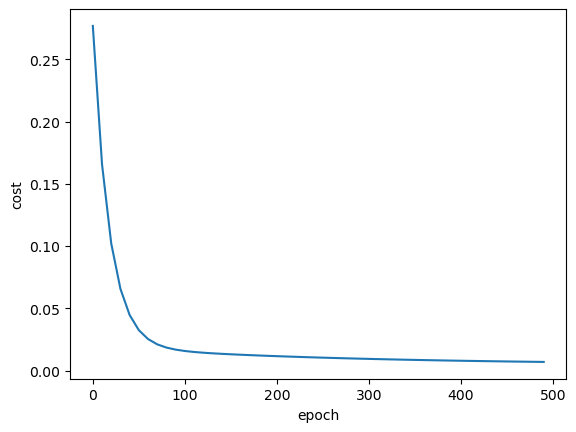

In [8]:
plt.xlabel('epoch')
plt.ylabel('cost')
plt.plot(epochlist,costlist)

In [10]:
def predict(area,bedrooms,w,b):
    scX=sx.transform([[area,bedrooms]])[0]
    scP=w[0]*scX[0]+w[1]*scX[1]+b
    return sy.inverse_transform([[scP]])[0][0]

predict(2600,4,w,b)

C:\Users\manas\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(128.45484403267596)

In [11]:
predict(1000,2,w,b)

C:\Users\manas\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(30.253094462442355)

In [19]:
def stochasticGD(X,yt,epochs,lr=0.01):
    nof=X.shape[1]
    w=np.ones(shape=(nof))
    b=0
    ts=X.shape[0]
    costlist=[]
    epochlist=[]
    for i in range(epochs):
        import random
        randInd=random.randint(0,ts-1)
        samx=X[randInd]
        samy=yt[randInd]
        yp=np.dot(w,samx)+b
        error = samy - yp
        wg = -2 * samx * error
        bg = -2 * error
        w=w-lr*wg
        b=b-lr*bg
        cost=np.square(samy-yp)
        if i%100==0:
            costlist.append(cost)
            epochlist.append(i)
    return w,b,cost,costlist,epochlist

In [20]:
wsgd,bsgd,coatSgd,costlistSgd,epochlistSgd=stochasticGD(scX,scY.reshape(scY.shape[0],),10000)
wsgd,bsgd,coatSgd

(array([0.8343045 , 0.29930158]),
 np.float64(-0.0953197496806228),
 np.float64(0.002144505092285585))

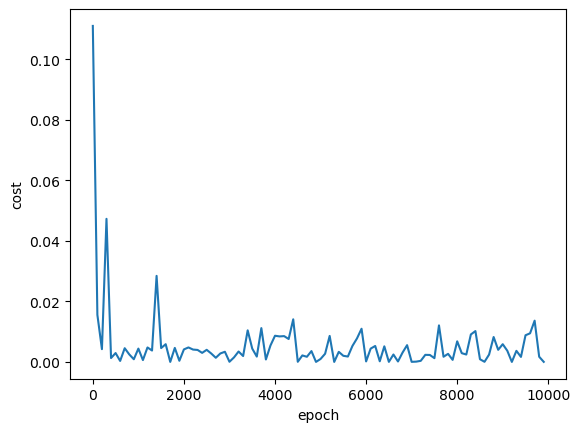

In [21]:
plt.xlabel('epoch')
plt.ylabel('cost')
plt.plot(epochlistSgd,costlistSgd)

In [22]:
predict(2600,4,wsgd,bsgd)

C:\Users\manas\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(119.34508177567865)

In [23]:
def minibatchGD(X, yt, epochs, batch_size = 5, lr = 0.01):
    nof = X.shape[1]
    w = np.ones(shape=(nof)) 
    b = 0
    ts = X.shape[0]
    
    cost_list = []
    epoch_list = []
    
    for i in range(epochs):
        indices = np.random.permutation(ts)
        Xs = X[indices]
        ys = yt[indices]
        for j in range(0, ts, batch_size):
            X_batch = Xs[j:j+batch_size]
            y_batch = ys[j:j+batch_size]
            yp = np.dot(X_batch, w) + b
            error = y_batch - yp
            wg = -(2/len(X_batch)) * (X_batch.T.dot(error))
            bg = -(2/len(X_batch)) * np.sum(error)
            w = w - lr * wg
            b = b - lr * bg
        cost = np.mean(np.square(yt - (np.dot(X, w) + b)))
        
        if i % 10 == 0: 
            cost_list.append(cost)
            epoch_list.append(i)
        
    return w, b, cost, cost_list, epoch_list

In [24]:
wmbgd,bmbgd,costMbgd,costlistMbgd,epochlistMbgd=minibatchGD(scX,scY.reshape(scY.shape[0],),10000)
wmbgd,bmbgd,costMbgd

(array([0.92149818, 0.2035683 ]),
 np.float64(-0.07438852559130439),
 np.float64(0.0028857480648264004))

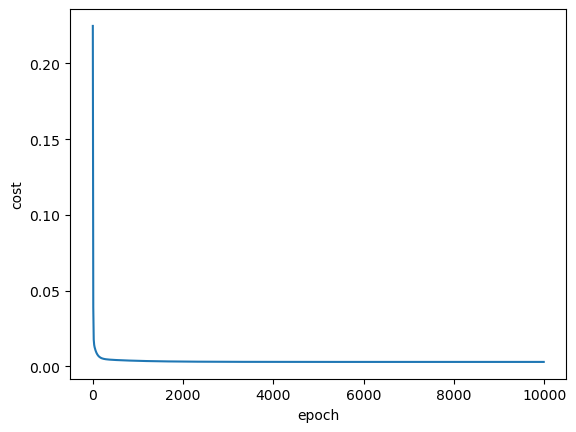

In [25]:
plt.xlabel('epoch')
plt.ylabel('cost')
plt.plot(epochlistMbgd,costlistMbgd)